![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/notebooks_banner_withframe.png)

# Converting GeoTIFF (.tif) to Shapefile (.shp) Format

Author details: Dr Ryan Newis

Editor details: Xiang Zhao

Contact details: support\@ecocommons.org.au

Copyright statement: This script is the product of the EcoCommons platform. Please refer to the EcoCommons website for more details: <https://www.ecocommons.org.au/>

Date: Feb 2026

# Script and Data Information

This notebook provides a simple, reproducible example of converting a GeoTIFF raster (.tif) into a vector shapefile (.shp) using the `terra` package in R. It is intended as a lightweight template that can be adapted to other raster-based spatial datasets and workflows requiring vector outputs.

## Other file formats of this notebook

| Notebook | Files | Open in Colab / ARDC Jupyter | DOI |
|:---:|:---:|:---:|:---:|
| Converting GeoTIFF (.tif) to Shapefile (.shp) Format | <a href="https://github.com/ecocommonsaustralia/notebooks/blob/main/notebooks/converting_geotiff_to_shapefile_notebook.ipynb"><img src="https://github.com/ecocommonsaustralia/notebooks/raw/main/assets/jupyter_notebook.png" width="40%"></a>&nbsp;&nbsp;<a href="https://github.com/ecocommonsaustralia/notebooks/blob/main/notebooks/converting_geotiff_to_shapefile_notebook.qmd"><img src="https://github.com/ecocommonsaustralia/notebooks/raw/main/assets/quartomd.png" width="40%"></a> | [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecocommonsaustralia/notebooks/blob/main/notebooks/converting_geotiff_to_shapefile_notebook.ipynb) | [![DOI](https://img.shields.io/badge/DOI-10.5281%2Fzenodo.19379843-blue)](https://doi.org/10.5281/zenodo.19379843) |

# Introduction

Raster and vector data represent two fundamental formats for storing spatial information. Raster datasets (e.g. GeoTIFF) store values in a grid of cells, while vector datasets (e.g. shapefile) represent spatial features as points, lines, or polygons. In many ecological and environmental workflows, it is necessary to convert raster data into vector polygons to enable integration with other vector-based datasets or modelling tools.

Although format conversion is often treated as a straightforward technical step, preserving spatial metadata during this process is essential. Changes to the coordinate reference system (CRS) or spatial extent can introduce subtle spatial misalignment that may not be immediately visible but can affect downstream analyses and modelling results.

This notebook demonstrates a structured and transparent approach to converting a GeoTIFF raster to a polygon shapefile while explicitly verifying that key spatial properties, including CRS, extent, and geometry validity are maintained.

# Key Concepts

## K.1 Raster data structure

Raster datasets represent spatial information as a regular grid of cells, where each cell contains a value corresponding to a measured or modelled variable. Raster formats are well suited to continuous surfaces such as climate variables, elevation, or habitat suitability layers.

## K.2 Vector data and shapefiles

Vector datasets represent spatial features as points, lines, or polygons. A shapefile (.shp) is a widely used vector format that stores geometric features alongside associated attribute information. Vector formats are commonly used for boundaries, administrative regions, and feature-based spatial analysis.

## K.3 Raster-to-vector conversion (polygonisation)

Converting raster data to vector format involves transforming raster cells into polygon features. During this process, adjacent cells with the same value can be merged into single polygons to produce cleaner, more interpretable outputs. This transformation enables raster-derived information to be integrated with vector-based workflows and spatial analysis tools.

# Notebook Objectives

1.  Demonstrate how to read a GeoTIFF (.tif) raster file into R as a SpatRaster using the `terra` package.
2.  Perform a basic visual check (plot) to confirm that the raster has been loaded correctly.
3.  Convert the raster to a polygon shapefile (.shp) format and save the output while preserving the original file naming and providing a transparent output location.
4.  Verify that key spatial metadata (CRS, extent, and geometry validity) are preserved during the conversion process.

# Workflow Overview

This notebook follows a simple, linear workflow to convert a GeoTIFF raster to a polygon shapefile (.shp) format via the following steps:

-   Step 1: Set up the R environment and load the required packages (`terra`, `sf` and `googledrive`).
-   Step 2: Define and validate the file path to the input GeoTIFF (.tif) raster.
-   Step 3: Read the raster into R as a SpatRaster object and confirm that a valid CRS is defined.
-   Step 4: Perform a visual check by plotting the raster to confirm it was read correctly.
-   Step 5: Convert the raster to polygon features and write the resulting layer to disk as a shapefile (.shp), preserving the original file name and providing a transparent output location.
-   Step 6: Validate that CRS, spatial extent, and geometry integrity are preserved after conversion.

**Important:** Converting continuous raster surfaces to shapefile format (.shp) may result in loss of numeric precision due to limitations of the shapefile format. For continuous prediction surfaces, retaining raster format (e.g., GeoTIFF) is strongly recommended.

In the near future, this material may form part of comprehensive support materials available to EcoCommons users. If you have any corrections or suggestions to improve the efficiency, please [contact the EcoCommons](mailto:support@ecocommons.org.au) team.

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_breaker_nobackgoundcolor.png)

# Step 1. Install and load required packages

Install and load R packages that are not already present in the working environment. For this notebook, the `terra`, `sf` and `googledrive` packages are required for converting a GeoTIFF (.tif) raster to a Shapefile (.shp) and for verifying spatial metadata during the workflow.


In [1]:

# Install and load required packages (if not already installed)
required_packages <- c(
  "terra",
  "googledrive",
  "sf"
)

for (pkg in required_packages) {

  # Install if missing
  if (!pkg %in% installed.packages()[, "Package"]) {
    install.packages(pkg)
    cat("Package installed successfully:", pkg, "\n")
  }

  # Load quietly
  suppressPackageStartupMessages(
    library(pkg, character.only = TRUE)
  )

  cat("Package loaded successfully:", pkg, "\n")
}


Package loaded successfully: terra 
Package loaded successfully: googledrive 
Package loaded successfully: sf 



# Step 2. Define the path to the input GeoTIFF raster file

We have provided an example GeoTIFF (`.tif`) for this notebook via OPTION 2 – Google Drive. If you would like to use your own GeoTIFF, choose OPTION 1, commenting out this line:

`tif_file <- NULL`

and uncomment this line with your updated path:

`tif_file <- "/path_to_your_file`

The example GeoTIFF is a binary prediction of suitable habitat for a modelled bird species. Converting a raster (.tif) to polygons (.shp) is generally recommended for categorical rasters or rasters that have been reclassified into a small number of categories, rather than for continuous prediction rasters (a common output of species distribution modelling).

Note: The input GeoTIFF raster must have a valid Coordinate Reference System (CRS) defined. If the file does not contain CRS information, the conversion will stop.


In [2]:

# OPTION 1: User-defined local GeoTIFF file
tif_file <- NULL
#tif_file <- "/path_to_your_file"


# OPTION 2: Download example GeoTIFF if no local file
if (is.null(tif_file)) {

  drive_deauth()

  workspace <- getwd()
  datafolder_path <- file.path(workspace, "data")

  if (!dir.exists(datafolder_path)) {
    dir.create(datafolder_path, recursive = TRUE)
  }

  tif_file_id <- "18_wS_vmeZRACysRJUdyM_UaZwPLXHdoa"

  # Get file metadata (to retrieve original name)
  file_info <- drive_get(as_id(tif_file_id))

  # Build full local path using original filename
  tif_file <- file.path(datafolder_path, file_info$name)

  # Download to that exact file path
  drive_download(
    as_id(tif_file_id),
    path = tif_file,
    overwrite = TRUE
  )
}

# Final safety check
if (!file.exists(tif_file)) {
  stop("Input GeoTIFF file not found.")
}

# Extract base file name (used downstream)
base_name <- tools::file_path_sans_ext(basename(tif_file))


File downloaded:

• example_binary_prediction_raster.tif <id: 18_wS_vmeZRACysRJUdyM_UaZwPLXHdoa>

Saved locally as:

• /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/example_binary_prediction_raster.tif




# Step 3. Read GeoTIFF raster into R

The rast() function reads the GeoTIFF (.tif) file into R as a SpatRaster object.


In [3]:

# Read the GeoTIFF into R as a SpatRaster object
input_raster <- rast(tif_file)

cat("CRS of input raster:\n")
print(crs(input_raster))

# Stop if CRS is missing
if (is.na(crs(input_raster)) || crs(input_raster) == "") {
  stop(
    "❌ Input GeoTIFF raster has NO CRS defined.\n",
    "Please ensure the file has a valid CRS before proceeding."
  )
}


CRS of input raster:
[1] "GEOGCRS[\"WGS 84\",\n    ENSEMBLE[\"World Geodetic System 1984 ensemble\",\n        MEMBER[\"World Geodetic System 1984 (Transit)\"],\n        MEMBER[\"World Geodetic System 1984 (G730)\"],\n        MEMBER[\"World Geodetic System 1984 (G873)\"],\n        MEMBER[\"World Geodetic System 1984 (G1150)\"],\n        MEMBER[\"World Geodetic System 1984 (G1674)\"],\n        MEMBER[\"World Geodetic System 1984 (G1762)\"],\n        MEMBER[\"World Geodetic System 1984 (G2139)\"],\n        MEMBER[\"World Geodetic System 1984 (G2296)\"],\n        ELLIPSOID[\"WGS 84\",6378137,298.257223563,\n            LENGTHUNIT[\"metre\",1]],\n        ENSEMBLEACCURACY[2.0]],\n    PRIMEM[\"Greenwich\",0,\n        ANGLEUNIT[\"degree\",0.0174532925199433]],\n    CS[ellipsoidal,2],\n        AXIS[\"geodetic latitude (Lat)\",north,\n            ORDER[1],\n            ANGLEUNIT[\"degree\",0.0174532925199433]],\n        AXIS[\"geodetic longitude (Lon)\",east,\n            ORDER[2],\n            


# Step 4. Plot raster

Plot the raster to confirm that it has been read correctly into R before proceeding with conversion. At this stage, the raster exists only as an in-memory SpatRaster object and has not yet been converted or written to disk.


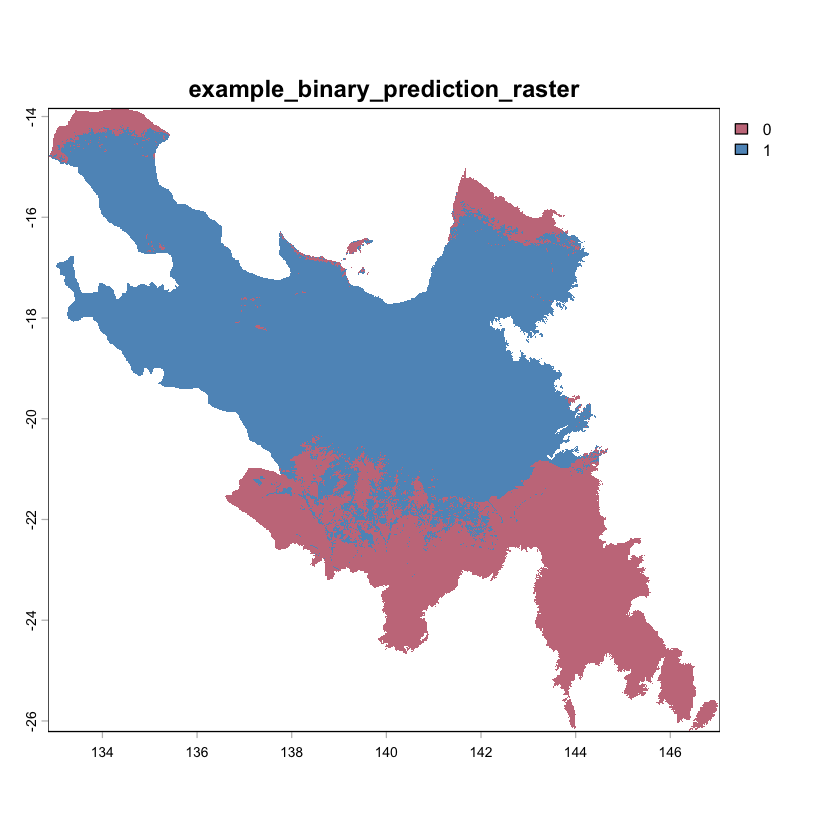

In [4]:


#plot(input_raster, main  = base_name)

# Ensure raster is treated as categorical
input_raster <- as.factor(input_raster)

# Get number of classes
n_classes <- length(unique(values(input_raster)))

# Define stable palette (better than rainbow)
pal <- hcl.colors(n_classes, "Dark2")

# Plot raster with consistent palette
plot(input_raster,
     col = pal,
     main = base_name)



# Step 5. Convert raster to polygon and save shapefile

Now convert the raster to a shapefile and also save and plot the converted file. By default, the output is written to the same directory as the input raster (.tif) file. We also produce a plot to visually check the GeoTIFF (.tif) to Shapefile (.shp) conversion.


Warning message in x@pntr$write(filename, layer, filetype, insert[1], overwrite[1], :
“GDAL Message 6: dataset /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/example_binary_prediction_raster_converted.shp does not support layer creation option OVERWRITE”


Shapefile written to:
 /Users/xiangzhaoqcif/dev/notebooks_zhaoxiangmax/notebooks/data/example_binary_prediction_raster_converted.shp 


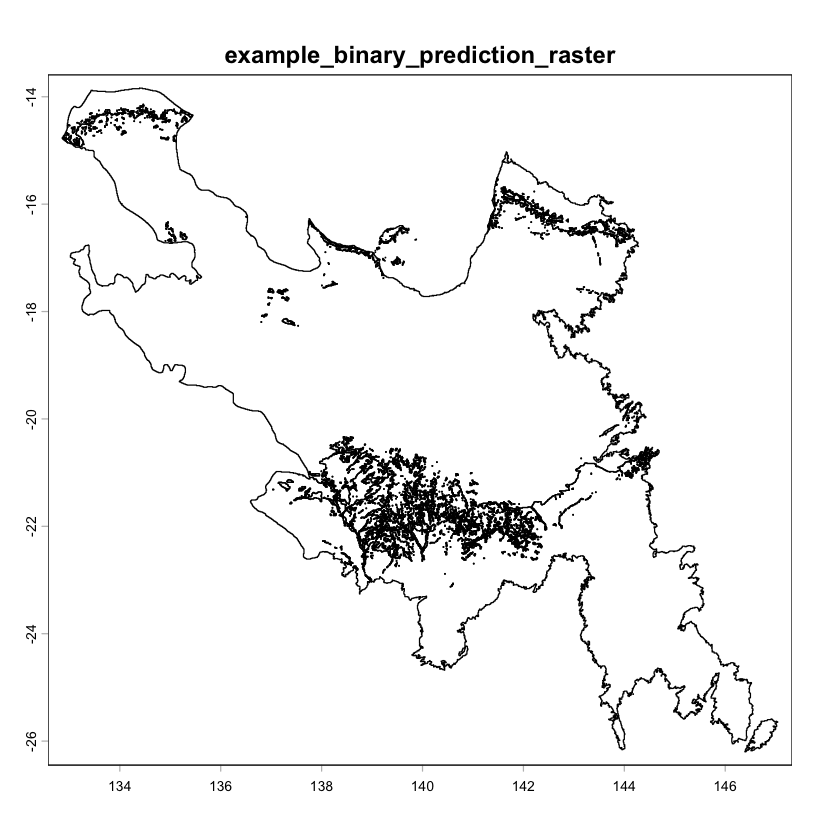

In [5]:

# Convert raster to polygons
# dissolve = TRUE merges adjacent cells with the same value
polygon_vector <- as.polygons(
  input_raster,
  dissolve = TRUE
)

# Save .shp output file to the same folder as the input raster
out_dir <- dirname(tif_file)

# Build the output file name (using previously defined base_name)
out_file  <- file.path(out_dir, paste0(base_name, "_converted.shp"))

# Write shapefile
writeVector(
  polygon_vector,
  out_file,
  overwrite = TRUE
)

cat("Shapefile written to:\n", out_file, "\n")

plot(polygon_vector, main = base_name)



# Step 6. Verify spatial metadata after writing shapefile

Reload the shapefile and confirm that CRS, extent, and geometry integrity have been preserved.


In [6]:

# Reload written shapefile
written_vector <- vect(out_file)

# CRS check

# Extract CRS info for input raster
input_crs_info <- terra::crs(input_raster, describe = TRUE)
input_crs_name <- input_crs_info$name
input_epsg <- input_crs_info$code

# Extract CRS info for output vector
output_crs_info <- terra::crs(written_vector, describe = TRUE)
output_crs_name <- output_crs_info$name
output_epsg <- output_crs_info$code

cat("\nInput CRS name:", input_crs_name, "\n")
cat("Input EPSG code:", input_epsg, "\n")

cat("\nOutput CRS name:", output_crs_name, "\n")
cat("Output EPSG code:", output_epsg, "\n")

# Validate CRS
if (!same.crs(input_raster, written_vector)) {
  stop("❌ CRS mismatch detected after writing shapefile.")
}

# Extent check
cat("\nInput raster extent:\n")
print(ext(input_raster))

cat("\nOutput vector extent:\n")
print(ext(written_vector))

input_ext  <- as.vector(terra::ext(input_raster))
output_ext <- as.vector(terra::ext(written_vector))

if (max(abs(input_ext - output_ext)) > 0.02) {
  stop("❌ Extent mismatch beyond acceptable tolerance.")
}


# Geometry validity check

# Convert to sf for geometry validation
written_sf <- sf::st_as_sf(written_vector)

if (!all(sf::st_is_valid(written_sf))) {
  stop("❌ Invalid geometries detected in output shapefile.")
}

cat("\n✅ All spatial metadata successfully preserved during conversion.\n")

plot


Input CRS name: WGS 84 
Input EPSG code: 4326 

Output CRS name: WGS 84 
Output EPSG code: 4326 

Input raster extent:
SpatExtent : 132.85, 147.05, -26.21, -13.84 (xmin, xmax, ymin, ymax)

Output vector extent:
SpatExtent : 132.86, 147.04, -26.2, -13.84 (xmin, xmax, ymin, ymax)

✅ All spatial metadata successfully preserved during conversion.


new("standardGeneric", .Data = function (x, y, ...) 
standardGeneric("plot"), generic = "plot", package = "base", 
    group = list(), valueClass = character(0), signature = c("x", 
    "y"), default = new("derivedDefaultMethod", .Data = function (x, 
        y, ...) 
    UseMethod("plot"), target = new("signature", .Data = "ANY", 
        names = "x", package = "methods"), defined = new("signature", 
        .Data = "ANY", names = "x", package = "methods"), generic = "plot"), 
    skeleton = (new("derivedDefaultMethod", .Data = function (x, 
        y, ...) 
    UseMethod("plot"), target = new("signature", .Data = "ANY", 
        names = "x", package = "methods"), defined = new("signature", 
        .Data = "ANY", names = "x", package = "methods"), generic = "plot"))(x, 
        y, ...))
<environment: 0x12be5fd80>
attr(,"generic")
[1] "plot"
attr(,"generic")attr(,"package")
[1] "base"
attr(,"package")
[1] "base"
attr(,"group")
list()
attr(,"valueClass")
character(0)
attr(,"signature")
[1] "x" "y"
attr(,"default")
Method Definition (Class "derivedDefaultMethod"):

function (x, y, ...) 
UseMethod("plot")
<bytecode: 0x12be2f4a8>
<environment: namespace:base>

Signatures:
        x    
target  "ANY"
defined "ANY"
attr(,"skeleton")
(new("derivedDefaultMethod", .Data = function (x, y, ...) 
UseMethod("plot"), target = new("signature", .Data = "ANY", names = "x", 
    package = "methods"), defined = new("signature", .Data = "ANY", 
    names = "x", package = "methods"), generic = "plot"))(x, 
    y, ...)
attr(,"class")
[1] "standardGeneric"
attr(,"class")attr(,"package")
[1] "methods"


# Summary

This notebook demonstrated a simple, reproducible workflow for converting a GeoTIFF (.tif) raster into a polygon shapefile (.shp) format using the `terra` and `sf` packages in R, while explicitly verifying that key spatial metadata and geometry integrity were preserved during conversion.

A companion notebook (link below) demonstrates the reverse workflow, converting a shapefile (.shp) to GeoTIFF format.

[Converting Shapefile (.shp) to GeoTIFF (.tif) Format](https://ecocommonsaustralia.github.io/notebook-blog/notebooks/raster_format/converting_shapefile_to_geotiff_notebook.html)

![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/EC_breaker_nobackgoundcolor.png)

EcoCommons received investment (<https://doi.org/10.3565/chbq-mr75>) from the Australian Research Data Commons (ARDC). The ARDC is enabled by the National Collaborative Research Infrastructure Strategy (NCRIS).


**Our Partners**


![](https://raw.githubusercontent.com/EcoCommons-Australia-2024-2026/ec-notebook_site/main/images/updated_ourpartner_2025.png)

## How to cite this Notebook

Newis, R., & Zhao, X. Y. (2026). *Converting GeoTIFF (.tif) to Shapefile (.shp) Format* (Version 1.0) [Computational notebook]. Zenodo. <https://doi.org/10.5281/zenodo.19379843>

# How to Cite EcoCommons

If you use EcoCommons in your research, please cite the platform as follows:

> EcoCommons Australia 2026. *EcoCommons Australia – a collaborative commons for ecological and environmental modelling*, Queensland Cyber Infrastructure Foundation, Brisbane, Queensland. Available at: <https://data–explorer.app.ecocommons.org.au/> (Accessed: MM DD, YYYY). <https://doi.org/10.3565/chbq-mr75>

You can download the citation file for EcoCommons Australia here: [Download the BibTeX file](reference.bib)